# Fast-Weight Language Model: a transformer alternative with test-time memory

This notebook builds and trains a small language model whose sequence-mixing layer is a **fast-weight memory** instead of self-attention.

**The idea.** Each layer keeps a small matrix `W` per head. For every token, the layer takes one gradient-descent step on `W` *while it reads*:

$$\mathcal{L}_t = \tfrac12 \lVert W k_t - v_t \rVert^2 \quad\Rightarrow\quad W_t = W_{t-1} + \beta_t\,(v_t - W_{t-1}k_t)\,k_t^\top$$

The output is a read from the updated memory: $o_t = W_t q_t$. This is the *delta rule* (the same family as DeltaNet and test-time-training layers).

**Why it's interesting**
- Memory is a fixed-size matrix, so generation needs **no KV cache** and costs constant memory per token.
- The layer *learns at inference time*, blurring the line between training and using a model.

**What's in this notebook**
1. The model (fast-weight layer, plus attention and MLP-only baselines)
2. Training a character-level language model on tiny Shakespeare
3. An associative-recall experiment that tests whether the memory really stores and retrieves information

## 0. Setup

In [6]:
%pip install -q torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import random
import ssl
import urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__)

device: cpu | torch 2.10.0


## 1. The model

**`FastWeightMemory`** is a drop-in replacement for self-attention:

1. Project the input to queries, keys and values, then run a short causal depthwise convolution over them. The convolution gives each position a peek at its few previous tokens, which lets the memory bind a token to the one before it (this is how DeltaNet-style layers handle things like "key then value" pairs).
2. L2-normalise queries and keys to keep the update stable.
3. For each time step: predict with the current memory, measure the error, and update the memory (the delta rule above). `beta` is predicted per token and per head, so the model decides how strongly to write.
4. Read from memory with the query.

The layer's `state` is `(W, conv_buffer)`, a fixed size regardless of how many tokens have been processed.

The time loop is sequential, so this version is clear but slow. Real implementations use chunked parallel algorithms and custom kernels.

In [9]:
class FastWeightMemory(nn.Module):
    def __init__(self, d_model, n_heads, conv_size=4):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dh = d_model // n_heads
        self.ks = conv_size
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        # depthwise causal conv (we pad manually so state can be carried across calls)
        self.conv = nn.Conv1d(3 * d_model, 3 * d_model, conv_size, groups=3 * d_model)
        self.beta = nn.Linear(d_model, n_heads)  # per-token, per-head "learning rate"
        self.out = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, state=None):
        B, T, D = x.shape
        W, buf = state if state is not None else (None, None)

        qkv = self.qkv(x).transpose(1, 2)  # (B, 3D, T)
        if buf is None:
            buf = qkv.new_zeros(B, qkv.size(1), self.ks - 1)
        inp = torch.cat([buf, qkv], dim=-1)  # (B, 3D, T + ks - 1)
        new_buf = inp[..., -(self.ks - 1):]
        qkv = F.silu(self.conv(inp)).transpose(1, 2)  # (B, T, 3D)

        q, k, v = qkv.reshape(B, T, 3, self.h, self.dh).unbind(2)  # each (B, T, H, dh)
        q = F.normalize(q, dim=-1)
        k = F.normalize(k, dim=-1)
        beta = torch.sigmoid(self.beta(x))  # (B, T, H)

        if W is None:
            W = x.new_zeros(B, self.h, self.dh, self.dh)

        outs = []
        for t in range(T):
            kt, vt, qt = k[:, t], v[:, t], q[:, t]  # (B, H, dh)
            bt = beta[:, t].unsqueeze(-1)  # (B, H, 1)
            pred = torch.einsum("bhij,bhj->bhi", W, kt)  # what memory says for key k
            err = vt - pred  # how wrong it is
            W = W + torch.einsum("bhi,bhj->bhij", bt * err, kt)  # one "learning" step
            outs.append(torch.einsum("bhij,bhj->bhi", W, qt))  # read with the query

        y = torch.stack(outs, dim=1).reshape(B, T, D)
        return self.out(y), (W, new_buf)

Now the blocks and the full model. Besides the fast-weight block, we define two baselines used in the recall experiment:

- **`AttentionBlock`**: standard causal self-attention (needs positional embeddings)
- **`MLPBlock`**: no mixing between positions at all, so it cannot see earlier tokens (a sanity-check floor)

In [11]:
def make_mlp(d):
    return nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))


class FastWeightBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1, self.mem = nn.LayerNorm(d), FastWeightMemory(d, h)
        self.ln2, self.mlp = nn.LayerNorm(d), make_mlp(d)

    def forward(self, x, state=None):
        h, state = self.mem(self.ln1(x), state)
        x = x + h
        return x + self.mlp(self.ln2(x)), state


class AttentionBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.ln2, self.mlp = nn.LayerNorm(d), make_mlp(d)

    def forward(self, x, state=None):
        T = x.size(1)
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=x.device), 1)
        h = self.ln1(x)
        h, _ = self.attn(h, h, h, attn_mask=mask, need_weights=False)
        x = x + h
        return x + self.mlp(self.ln2(x)), None


class MLPBlock(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln, self.mlp = nn.LayerNorm(d), make_mlp(d)

    def forward(self, x, state=None):
        return x + self.mlp(self.ln(x)), None


BLOCKS = {"fastweight": FastWeightBlock, "attention": AttentionBlock, "mlp_only": MLPBlock}


class SeqModel(nn.Module):
    def __init__(self, vocab, kind="fastweight", d_model=128, n_heads=4, n_layers=3, max_len=512):
        super().__init__()
        self.emb = nn.Embedding(vocab, d_model)
        # attention has no notion of order, so it needs positional embeddings
        self.pos = nn.Embedding(max_len, d_model) if kind == "attention" else None
        self.blocks = nn.ModuleList([BLOCKS[kind](d_model, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab, bias=False)

    def forward(self, idx, states=None):
        x = self.emb(idx)
        if self.pos is not None:
            x = x + self.pos(torch.arange(idx.size(1), device=idx.device))
        states = states or [None] * len(self.blocks)
        new_states = []
        for blk, s in zip(self.blocks, states):
            x, s = blk(x, s)
            new_states.append(s)
        return self.head(self.ln_f(x)), new_states

    @torch.no_grad()
    def generate(self, idx, n_new, temperature=0.8):
        # fast-weight models only: carry the memory state, never a KV cache
        logits, states = self(idx)  # read the prompt; the memory absorbs it
        for _ in range(n_new):
            probs = F.softmax(logits[:, -1] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1)
            idx = torch.cat([idx, nxt], dim=1)
            logits, states = self(nxt, states)  # one token at a time
        return idx


def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 2. Character-level language model on tiny Shakespeare

First we check that the model can learn language at all. The download helper tries a normal request, then a request using the `certifi` certificate bundle (this fixes the common macOS `CERTIFICATE_VERIFY_FAILED` error), and otherwise tells you what to run in a terminal.

In [13]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"


def load_text(path="input.txt"):
    if not os.path.exists(path):
        contexts = [None]
        try:
            import certifi
            contexts.append(ssl.create_default_context(cafile=certifi.where()))
        except ImportError:
            pass
        for ctx in contexts:
            try:
                with urllib.request.urlopen(URL, context=ctx) as r:
                    data = r.read()
                with open(path, "wb") as f:
                    f.write(data)
                break
            except Exception as e:
                print("download attempt failed:", e)
        else:
            raise RuntimeError(f"Download failed. Run this in a terminal, then re-run the cell:\n  curl -o {path} {URL}")
    return open(path, encoding="utf-8").read()


text = load_text()
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print(f"{len(text):,} characters | vocab size {len(chars)}")

1,115,394 characters | vocab size 65


In [14]:
LM_STEPS, LM_BATCH, LM_SEQ, LM_LR = 1500, 32, 64, 3e-3   # raise LM_STEPS (e.g. 5000) for better text


def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - LM_SEQ - 1, (LM_BATCH,))
    x = torch.stack([d[i : i + LM_SEQ] for i in ix]).to(device)
    y = torch.stack([d[i + 1 : i + LM_SEQ + 1] for i in ix]).to(device)
    return x, y


lm = SeqModel(len(chars), "fastweight", d_model=128, n_heads=4, n_layers=3).to(device)
print(f"{n_params(lm) / 1e6:.2f}M parameters")
opt = torch.optim.AdamW(lm.parameters(), lr=LM_LR)

history = []  # (step, train_loss, val_loss)
for step in range(LM_STEPS + 1):
    x, y = get_batch("train")
    logits, _ = lm(x)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lm.parameters(), 1.0)
    opt.step()

    if step % 100 == 0:
        with torch.no_grad():
            xv, yv = get_batch("val")
            lv, _ = lm(xv)
            vl = F.cross_entropy(lv.reshape(-1, lv.size(-1)), yv.reshape(-1)).item()
        history.append((step, loss.item(), vl))
        print(f"step {step:5d} | train {loss.item():.3f} | val {vl:.3f}")

0.62M parameters
step     0 | train 4.314 | val 3.447
step   100 | train 1.964 | val 2.099
step   200 | train 1.884 | val 2.042
step   300 | train 1.729 | val 1.941
step   400 | train 1.681 | val 1.897
step   500 | train 1.634 | val 1.786
step   600 | train 1.585 | val 1.764
step   700 | train 1.614 | val 1.883
step   800 | train 1.573 | val 1.711
step   900 | train 1.547 | val 1.758
step  1000 | train 1.461 | val 1.751
step  1100 | train 1.476 | val 1.708
step  1200 | train 1.467 | val 1.719
step  1300 | train 1.540 | val 1.695
step  1400 | train 1.416 | val 1.662
step  1500 | train 1.483 | val 1.611


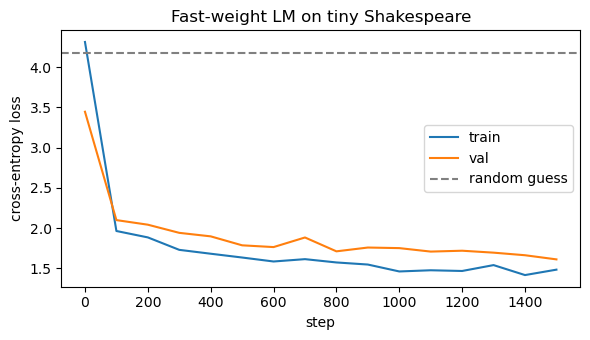

In [15]:
steps_, tr, va = zip(*history)
plt.figure(figsize=(6, 3.5))
plt.plot(steps_, tr, label="train")
plt.plot(steps_, va, label="val")
plt.axhline(torch.log(torch.tensor(float(len(chars)))).item(), color="gray", ls="--", label="random guess")
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.legend(); plt.title("Fast-weight LM on tiny Shakespeare")
plt.tight_layout(); plt.show()

In [16]:
lm.eval()
prompt = torch.tensor([[stoi[c] for c in "ROMEO:\n"]], device=device)
out = lm.generate(prompt, 500)[0].tolist()
print("".join(itos[i] for i in out))

ROMEO:
You have not lexs, I do not know a hooo.

LUCIO:
If it for love, whose for lions,
The blockedy of the company, and that not your prince.

ROMEO:
I be son: and I fou, Valy Clord,
The sport of my tongue of such'd-canding and.

POLIXENES:
Whence hears, affect hath him have forsh cousin,
But known now to Romeof, and way of the prayey
And feemin'd in the virst have bid hide! I look, combed. 
MENENIUS:

POMPHERDITABENRY ROvELIY:
You sport a stant of treagt,
Of yours time to the rude of this,

BENVOLIO


**Constant-memory generation.** The only thing carried between tokens is the memory state. A transformer's KV cache would instead grow with every token.

In [18]:
with torch.no_grad():
    _, states = lm(prompt)
n_state = sum(W.numel() + buf.numel() for W, buf in states)
n_layers, d_model = len(lm.blocks), 128
for T in (1_000, 10_000, 100_000):
    print(f"context {T:>7,} tokens | fast-weight state: {n_state:,} floats | transformer KV cache: {2 * n_layers * d_model * T:,} floats")

context   1,000 tokens | fast-weight state: 15,744 floats | transformer KV cache: 768,000 floats
context  10,000 tokens | fast-weight state: 15,744 floats | transformer KV cache: 7,680,000 floats
context 100,000 tokens | fast-weight state: 15,744 floats | transformer KV cache: 76,800,000 floats


## 3. Does the memory actually work? Associative recall

Language modelling can hide whether a layer is really using its memory. This synthetic task tests it directly.

The model sees a list of key→value pairs, then a query key, and must output the matching value:

```
k7 v3  k2 v9  k15 v1  ...  <QUERY> k2   →   v9
```

- 32 possible keys, 16 possible values, so **chance accuracy is 1/16 ≈ 6%**
- Training uses between 2 and 12 pairs per sequence
- Evaluation goes up to 24 pairs, beyond anything seen in training
- Each head's memory is a 32×32 matrix, so we expect retrieval to get harder as the number of stored pairs approaches that size

We compare three models: fast-weight, standard attention, and MLP-only (which cannot see earlier tokens, so it should stay at chance).

In [20]:
N_KEYS, N_VALS = 32, 16
QUERY = N_KEYS + N_VALS
RECALL_VOCAB = N_KEYS + N_VALS + 1


def make_recall_batch(batch, n_pairs):
    keys = torch.rand(batch, N_KEYS, device=device).argsort(dim=1)[:, :n_pairs]  # distinct keys
    vals = torch.randint(N_KEYS, N_KEYS + N_VALS, (batch, n_pairs), device=device)
    seq = torch.empty(batch, 2 * n_pairs, dtype=torch.long, device=device)
    seq[:, 0::2] = keys
    seq[:, 1::2] = vals
    j = torch.randint(0, n_pairs, (batch,), device=device)
    rows = torch.arange(batch, device=device)
    q = torch.full((batch, 1), QUERY, dtype=torch.long, device=device)
    x = torch.cat([seq, q, keys[rows, j].unsqueeze(1)], dim=1)
    return x, vals[rows, j]


@torch.no_grad()
def eval_recall(model, n_pairs, n=512):
    model.eval()
    x, target = make_recall_batch(n, n_pairs)
    logits, _ = model(x)
    return (logits[:, -1].argmax(-1) == target).float().mean().item()


def train_recall(kind, steps, batch=64, lr=2e-3, pair_range=(2, 12)):
    torch.manual_seed(SEED)
    model = SeqModel(RECALL_VOCAB, kind, d_model=64, n_heads=2, n_layers=2, max_len=64).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    curve = []  # (step, running accuracy)
    acc_acc = []
    for step in range(1, steps + 1):
        model.train()
        n_pairs = random.randint(*pair_range)
        x, target = make_recall_batch(batch, n_pairs)
        logits, _ = model(x)
        loss = F.cross_entropy(logits[:, -1], target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        acc_acc.append((logits[:, -1].argmax(-1) == target).float().mean().item())
        if step % 100 == 0:
            curve.append((step, sum(acc_acc) / len(acc_acc)))
            acc_acc = []
            print(f"[{kind:10s}] step {step:5d} | loss {loss.item():.3f} | train acc {curve[-1][1]:.2f}")
    return model, curve

In [21]:
RECALL_STEPS = 2000   # the attention baseline may need more steps to form "induction" circuits

results = {}
for kind in ("fastweight", "attention", "mlp_only"):
    print(f"\n=== {kind} ===")
    model, curve = train_recall(kind, RECALL_STEPS)
    results[kind] = (model, curve)


=== fastweight ===
[fastweight] step   100 | loss 2.553 | train acc 0.09
[fastweight] step   200 | loss 0.394 | train acc 0.45
[fastweight] step   300 | loss 0.009 | train acc 0.92
[fastweight] step   400 | loss 0.004 | train acc 0.99
[fastweight] step   500 | loss 0.025 | train acc 0.99
[fastweight] step   600 | loss 0.001 | train acc 0.99
[fastweight] step   700 | loss 0.001 | train acc 0.99
[fastweight] step   800 | loss 0.001 | train acc 1.00
[fastweight] step   900 | loss 0.001 | train acc 1.00
[fastweight] step  1000 | loss 0.001 | train acc 1.00
[fastweight] step  1100 | loss 0.000 | train acc 1.00
[fastweight] step  1200 | loss 0.000 | train acc 1.00
[fastweight] step  1300 | loss 0.000 | train acc 1.00
[fastweight] step  1400 | loss 0.039 | train acc 1.00
[fastweight] step  1500 | loss 0.002 | train acc 1.00
[fastweight] step  1600 | loss 0.002 | train acc 1.00
[fastweight] step  1700 | loss 0.000 | train acc 1.00
[fastweight] step  1800 | loss 0.000 | train acc 1.00
[fastwei

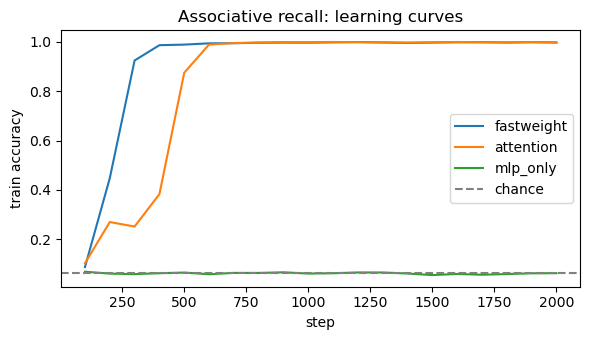

In [22]:
plt.figure(figsize=(6, 3.5))
for kind, (_, curve) in results.items():
    s, a = zip(*curve)
    plt.plot(s, a, label=kind)
plt.axhline(1 / N_VALS, color="gray", ls="--", label="chance")
plt.xlabel("step"); plt.ylabel("train accuracy"); plt.legend(); plt.title("Associative recall: learning curves")
plt.tight_layout(); plt.show()

pairs             2       4       8      12      16      24
fastweight     1.00    1.00    1.00    0.99    0.97    0.91
attention      0.99    1.00    1.00    1.00    0.77    0.42
mlp_only       0.07    0.06    0.06    0.06    0.05    0.05


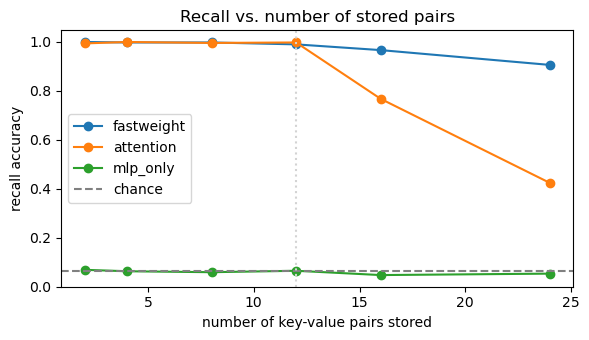

In [23]:
lengths = [2, 4, 8, 12, 16, 24]   # training used 2..12 pairs; 16 and 24 are unseen lengths
table = {kind: [eval_recall(m, L) for L in lengths] for kind, (m, _) in results.items()}

print("pairs      " + "".join(f"{L:>8d}" for L in lengths))
for kind, accs in table.items():
    print(f"{kind:10s} " + "".join(f"{a:8.2f}" for a in accs))

plt.figure(figsize=(6, 3.5))
for kind, accs in table.items():
    plt.plot(lengths, accs, marker="o", label=kind)
plt.axhline(1 / N_VALS, color="gray", ls="--", label="chance")
plt.axvline(12, color="lightgray", ls=":")
plt.xlabel("number of key-value pairs stored"); plt.ylabel("recall accuracy"); plt.legend()
plt.title("Recall vs. number of stored pairs"); plt.tight_layout(); plt.show()

## 4. Reading the results

- **MLP-only** should sit at chance (about 6%), confirming the task really requires remembering earlier tokens.
- **Fast-weight** is the interesting one: if its curve rises well above chance, the delta-rule memory is genuinely storing and retrieving key→value bindings. Its accuracy should fall as the number of stored pairs approaches the 32-dimensional capacity of each head's memory, and that degradation is the fixed-size-memory trade-off showing up.
- **Attention** can recall exactly (it keeps every token), but it needs enough training to form the circuit and it cannot extrapolate to sequence lengths whose positional embeddings were never trained.

Results will vary with the random seed and step count, so treat the numbers as a starting point rather than a benchmark.

## 5. Ideas to extend this

1. **Forgetting:** add a decay on `W` (`W = alpha_t * W + ...`) so old memories fade, as in Gated DeltaNet.
2. **Momentum / surprise-based updates:** make the inner loop use momentum, as in Titans.
3. **Chunkwise parallel training:** replace the Python time loop with a chunked algorithm for a large speed-up.
4. **Bigger memory:** try more heads or a larger `d_model` and re-run the capacity curve.
5. **Hybrid model:** mix a few attention layers with fast-weight layers and compare on both tasks.